## Phase 1 — Environment Setup & Data Loading

### 1.1 — Import Libraries

In [12]:
# ── Core ─────────────────────────────────────────────────────────────────────
import warnings
import os
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Data ─────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import (
    LabelEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# ── Gradient Boosting ─────────────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# ── Hyperparameter Optimisation ───────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)   # suppress per-trial noise

# ── SHAP (Model Explainability) ───────────────────────────────────────────────
import shap

# ── Display config ────────────────────────────────────────────────────────────
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✅ Libraries imported successfully")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   xgboost {xgb.__version__}")
print(f"   lightgbm {lgb.__version__}")
print(f"   optuna  {optuna.__version__}")
print(f"   shap    {shap.__version__}")

✅ Libraries imported successfully
   pandas  2.2.3
   numpy   2.1.3
   xgboost 3.2.0
   lightgbm 4.6.0
   optuna  4.9.0
   shap    0.52.0


### 1.2 — File Paths

In [13]:
# ── Resolve paths relative to this notebook ───────────────────────────────────
ROOT = Path(".")                                      # SpotterAssignment/
DATA = ROOT / "data"

TRAIN_PATH       = DATA / "train-test.csv"
VALIDATION_PATH  = DATA / "validation.csv"
DECEMBER_PATH    = DATA / "december-chart-inputs.csv"
TEMPLATE_PATH    = DATA / "validation-predictions-template.csv"

OUTPUT_PREDICTIONS = ROOT / "validation_predictions.csv"  # final submission file

# ── Verify every input file exists ────────────────────────────────────────────
all_paths = {
    "train-test.csv": TRAIN_PATH,
    "validation.csv": VALIDATION_PATH,
    "december-chart-inputs.csv": DECEMBER_PATH,
    "validation-predictions-template.csv": TEMPLATE_PATH,
}

print("File existence check:")
all_ok = True
for name, path in all_paths.items():
    exists = path.is_file()
    size_mb = path.stat().st_size / 1e6 if exists else 0
    status = "Present" if exists else "Missing"
    print(f"   {status}  {name:<45}  {size_mb:.2f} MB")
    if not exists:
        all_ok = False

if all_ok:
    print("All input files present.")
else:
    raise FileNotFoundError("One or more required input files are missing. Check the paths above.")

File existence check:
   Present  train-test.csv                                 5.96 MB
   Present  validation.csv                                 1.39 MB
   Present  december-chart-inputs.csv                      0.00 MB
   Present  validation-predictions-template.csv            0.13 MB
All input files present.


### 1.3 — Load CSVs & Parse Dates

In [14]:
# ── Load all datasets ─────────────────────────────────────────────────────────
df_train    = pd.read_csv(TRAIN_PATH,      parse_dates=["date"])
df_val      = pd.read_csv(VALIDATION_PATH, parse_dates=["date"])
df_dec      = pd.read_csv(DECEMBER_PATH,   parse_dates=["date"])
df_template = pd.read_csv(TEMPLATE_PATH)

print("All CSVs loaded.")

All CSVs loaded.


### 1.4 — Sanity Checks

In [15]:

def dataset_summary(df: pd.DataFrame, name: str) -> None:
    print("=" * 72)
    print(f" {name}")
    print("=" * 72)
    print(f"  Shape   : {df.shape[0]:,} rows , {df.shape[1]} columns")

    # Date range (if a date column exists)
    date_cols = [c for c in df.columns if pd.api.types.is_datetime64_any_dtype(df[c])]
    for dc in date_cols:
        print(f"  {dc:<10}: {df[dc].min().date()}  →  {df[dc].max().date()}")


    info = pd.DataFrame({
        "dtype"   : df.dtypes.astype(str),
        "non_null": df.notnull().sum(),
        "nulls"   : df.isnull().sum(),
        "null_%"  : (df.isnull().mean() * 100).round(2),
        "n_unique": df.nunique(),
        "sample"  : df.iloc[0].astype(str),
    })
    print()
    print(info.to_string())
    print()


dataset_summary(df_train,    "TRAIN  (train-test.csv)")
dataset_summary(df_val,      "VALIDATION  (validation.csv)")
dataset_summary(df_dec,      "DECEMBER CHART  (december-chart-inputs.csv)")
dataset_summary(df_template, "TEMPLATE  (validation-predictions-template.csv)")

 TRAIN  (train-test.csv)
  Shape   : 48,000 rows , 14 columns
  date      : 2025-01-01  →  2025-10-31

                       dtype  non_null  nulls  null_%  n_unique               sample
load_id               object     48000      0  0.0000     48000            TR-000001
pickup                object     48000      0  0.0000        64             Richmond
delivery              object     48000      0  0.0000        64            Baltimore
pickup_lat           float64     48000      0  0.0000        64             38.09122
pickup_lon           float64     48000      0  0.0000        63            -76.78906
delivery_lat         float64     48000      0  0.0000        64             38.16908
delivery_lon         float64     48000      0  0.0000        63            -72.74564
distance             float64     48000      0  0.0000     21204                274.3
equipment             object     48000      0  0.0000         3              Dry Van
weight               float64     47700    300  

In [16]:
# ── Quick target-variable peek ─────────────────────────────────────────────────
print("posted_rate — descriptive statistics")
print("-" * 45)
desc = df_train["posted_rate"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
for stat, val in desc.items():
    print(f"   {stat:<8}: ${val:>10,.2f}")

posted_rate — descriptive statistics
---------------------------------------------
   count   : $ 48,000.00
   mean    : $  2,373.98
   std     : $  1,486.49
   min     : $     57.22
   1%      : $    327.17
   5%      : $    599.74
   25%     : $  1,251.55
   50%     : $  2,030.76
   75%     : $  3,330.75
   95%     : $  4,953.77
   99%     : $  5,972.83
   max     : $ 25,533.00


In [17]:
# ── Missing-value overview across all datasets ────────────────────────────────
def missing_summary(df: pd.DataFrame, name: str) -> pd.DataFrame:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if nulls.empty:
        print(f"  {name}: no missing values ✅")
        return pd.DataFrame()
    result = pd.DataFrame({
        "missing": nulls,
        "pct": (nulls / len(df) * 100).round(2),
    })
    print(f"\n  {name} — missing values:")
    print(result.to_string())
    return result

print("🔍  Missing-value audit")
print("=" * 45)
missing_summary(df_train,    "TRAIN")
missing_summary(df_val,      "VALIDATION")
missing_summary(df_dec,      "DECEMBER")
missing_summary(df_template, "TEMPLATE")

🔍  Missing-value audit

  TRAIN — missing values:
              missing    pct
weight            300 0.6200
market_index      374 0.7800

  VALIDATION — missing values:
              missing    pct
weight            165 1.3800
market_index      249 2.0800

  DECEMBER — missing values:
                missing      pct
predicted_rate       31 100.0000

  TEMPLATE — missing values:
                missing      pct
predicted_rate    12000 100.0000


,missing,pct
predicted_rate,12000,100.0000


In [18]:
# ── Category counts ───────────────────────────────────────────────────────────
print("Equipment types in TRAIN:")
print(df_train["equipment"].value_counts().to_string())

print("\nEquipment types in VALIDATION:")
print(df_val["equipment"].value_counts().to_string())

print(f"\nUnique pickup  cities — train: {df_train['pickup'].nunique():>3}  |  val: {df_val['pickup'].nunique():>3}")
print(f"Unique delivery cities — train: {df_train['delivery'].nunique():>3}  |  val: {df_val['delivery'].nunique():>3}")

# New cities in validation not seen in training?
new_pickup   = set(df_val["pickup"])   - set(df_train["pickup"])
new_delivery = set(df_val["delivery"]) - set(df_train["delivery"])
print(f"New pickup cities in validation not in train   : {new_pickup  if new_pickup   else 'None'}")
print(f"New delivery cities in validation not in train : {new_delivery if new_delivery else 'None'}")

Equipment types in TRAIN:
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753

Equipment types in VALIDATION:
equipment
Dry Van    6780
Reefer     3051
Flatbed    2169

Unique pickup  cities — train:  64  |  val:  72
Unique delivery cities — train:  64  |  val:  72
New pickup cities in validation not in train   : {'Jackson', 'Allentown', 'Chicago', 'Knoxville', 'Laredo', 'San Diego', 'Norfolk', 'Charlotte'}
New delivery cities in validation not in train : {'Jackson', 'Allentown', 'Chicago', 'Knoxville', 'Laredo', 'San Diego', 'Norfolk', 'Charlotte'}


In [19]:
# ── Date continuity check ─────────────────────────────────────────────────────
print("Date ranges:")
print(f"   Train      : {df_train['date'].min().date()}  →  {df_train['date'].max().date()}")
print(f"   Validation : {df_val['date'].min().date()}  →  {df_val['date'].max().date()}")
print(f"   December   : {df_dec['date'].min().date()}  →  {df_dec['date'].max().date()}")

gap_days = (df_val["date"].min() - df_train["date"].max()).days
print(f"\n   Gap between last train date and first validation date: {gap_days} day(s)")

# Check for duplicated load_ids within each file
print("\nDuplicate load_id check:")
for name, df in [("TRAIN", df_train), ("VALIDATION", df_val)]:
    dup_count = df["load_id"].duplicated().sum()
    status = "None" if dup_count == 0 else f"{dup_count} duplicates!"
    print(f"   {name:<12}: {status}")

Date ranges:
   Train      : 2025-01-01  →  2025-10-31
   Validation : 2025-11-01  →  2025-12-31
   December   : 2025-12-01  →  2025-12-31

   Gap between last train date and first validation date: 1 day(s)

Duplicate load_id check:
   TRAIN       : None
   VALIDATION  : None


In [20]:
# ── Template vs Validation alignment ─────────────────────────────────────────
print("Template vs Validation alignment:")
template_ids = set(df_template["load_id"])
val_ids      = set(df_val["load_id"])

missing_in_template = val_ids - template_ids
extra_in_template   = template_ids - val_ids

print(f"   Template rows : {len(df_template):,}")
print(f"   Validation IDs: {len(df_val):,}")
print(f"   IDs in val but not template : {len(missing_in_template)}  {'✅' if not missing_in_template else '❌'}")
print(f"   IDs in template but not val : {len(extra_in_template)}   {'✅' if not extra_in_template   else '❌'}")

print("\n📋  December chart columns:")
print(f"   {list(df_dec.columns)}")
print(f"   Predicted_rate filled: {df_dec['predicted_rate'].notnull().sum()} / {len(df_dec)}")

Template vs Validation alignment:
   Template rows : 12,000
   Validation IDs: 12,000
   IDs in val but not template : 0  ✅
   IDs in template but not val : 0   ✅

📋  December chart columns:
   ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']
   Predicted_rate filled: 0 / 31


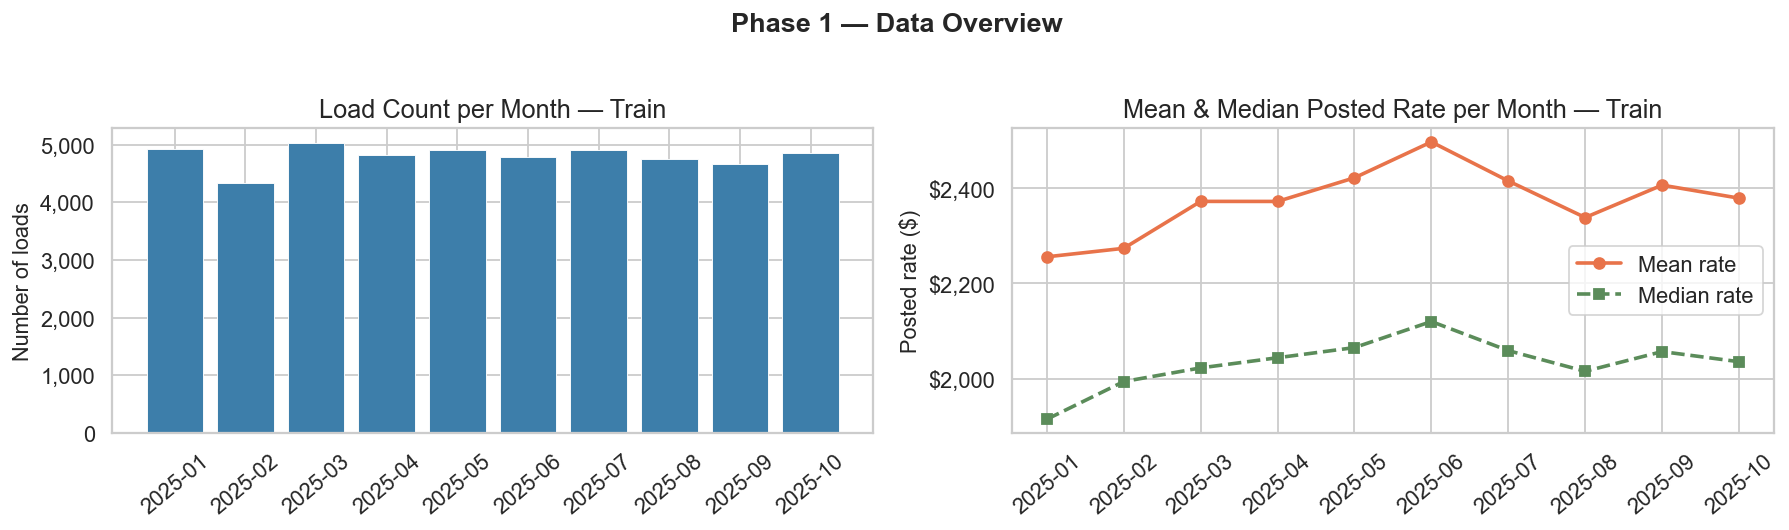

Phase 1 overview chart saved → phase1_overview.png


In [21]:
# ── Monthly load counts (train) — quick bar chart ─────────────────────────────
monthly = df_train.groupby(df_train["date"].dt.to_period("M"))["posted_rate"].agg(["count", "mean", "median"])
monthly.index = monthly.index.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Load count per month
axes[0].bar(monthly.index, monthly["count"], color="#3D7EAA", edgecolor="white", linewidth=0.5)
axes[0].set_title("Load Count per Month — Train")
axes[0].set_ylabel("Number of loads")
axes[0].tick_params(axis="x", rotation=40)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Mean & median rate per month
axes[1].plot(monthly.index, monthly["mean"],   marker="o", label="Mean rate",   color="#E8734A", linewidth=2)
axes[1].plot(monthly.index, monthly["median"], marker="s", label="Median rate", color="#5B8C5A", linewidth=2, linestyle="--")
axes[1].set_title("Mean & Median Posted Rate per Month — Train")
axes[1].set_ylabel("Posted rate ($)")
axes[1].tick_params(axis="x", rotation=40)
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

fig.suptitle("Phase 1 — Data Overview", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("phase1_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Phase 1 overview chart saved → phase1_overview.png")

In [22]:
# ── Final Phase 1 summary ─────────────────────────────────────────────────────
print("" + "=" * 60)
print("PHASE 1 COMPLETE — Environment Setup & Data Loading")
print("=" * 60)
print(f"  Train rows      : {len(df_train):>8,}   (target: posted_rate)")
print(f"  Validation rows : {len(df_val):>8,}   (predict these)")
print(f"  December rows   : {len(df_dec):>8,}   (fixed-route chart)")
print(f"  Template rows   : {len(df_template):>8,}   (output scaffold)")
print()
print("  Key observations:")
print(f"    • Temporal gap: train ends {df_train['date'].max().date()},"
      f" val starts {df_val['date'].min().date()}")
print(f"    • Missing weight      : {df_train['weight'].isnull().sum()} train rows"
      f" / {df_val['weight'].isnull().sum()} val rows")
print(f"    • Missing market_index: {df_train['market_index'].isnull().sum()} train rows"
      f" / {df_val['market_index'].isnull().sum()} val rows")
print(f"    • Equipment types     : {sorted(df_train['equipment'].unique())}")
print(f"    • Target mean/std     : ${df_train['posted_rate'].mean():,.2f} "
      f"/ ${df_train['posted_rate'].std():,.2f}")
print()
print("  Objects available for next phases:")
print("    df_train, df_val, df_dec, df_template")
print("=" * 60)

PHASE 1 COMPLETE — Environment Setup & Data Loading
  Train rows      :   48,000   (target: posted_rate)
  Validation rows :   12,000   (predict these)
  December rows   :       31   (fixed-route chart)
  Template rows   :   12,000   (output scaffold)

  Key observations:
    • Temporal gap: train ends 2025-10-31, val starts 2025-11-01
    • Missing weight      : 300 train rows / 165 val rows
    • Missing market_index: 374 train rows / 249 val rows
    • Equipment types     : ['Dry Van', 'Flatbed', 'Reefer']
    • Target mean/std     : $2,373.98 / $1,486.49

  Objects available for next phases:
    df_train, df_val, df_dec, df_template
